In [1]:
import numpy as np
import pandas as pd
import scipy.spatial
from scipy.sparse import lil_matrix, csgraph
import geopandas as gpd
import matplotlib.pyplot as plt

# Read data

In [2]:
nhf_path = '/home/akagi/Documents/Data/txswift/nhf_1.1.3.gpkg'
nhd_path = '/home/akagi/Documents/Data/GIS/NHD_H_Texas_State_GDB/NHD_H_Texas_State_GDB.gdb'
nhf_subbasins = gpd.read_file(nhf_path, layer='divides')
nhd_flowlines = gpd.read_file(nhd_path, layer=18)

/home/akagi/.local/lib/python3.11/site-packages/pyogrio/raw.py:196: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D MultiLineString' is converted to 'MultiLineString Z'
  return ogr_read(


# Clip to study area

In [3]:
xmin, ymin, xmax, ymax = nhf_subbasins.to_crs(nhd_flowlines.crs).total_bounds
nhd_flowlines = nhd_flowlines.cx[xmin:xmax, ymin:ymax]
nhd_flowlines = nhd_flowlines.reset_index(drop=True)
geom_array = nhd_flowlines.geometry

In [4]:
# Ensure multilinestrings are actually linestrings
assert max(geom_array.apply(lambda x: len(x.geoms)).values) == 1

# Create and query spatial index of start and end points of flowlines

In [5]:
coords = geom_array.apply(lambda x: x.geoms[0]).apply(lambda y: y.coords.xy)
x = coords.str[0]
y = coords.str[1]
x0, x1 = x.str[0], x.str[-1]
y0, y1 = y.str[0], y.str[-1]
p0 = np.column_stack([x0.values, y0.values])
p1 = np.column_stack([x1.values, y1.values])
xy = np.column_stack([np.concatenate(x.values), np.concatenate(y.values)])

tree = scipy.spatial.KDTree(xy)
arr_lens = x.apply(lambda x: len(x))
point_indices = np.repeat(arr_lens.index.values, arr_lens.values)
start_dists, start_indices = tree.query(p0, k=2)
end_dists, end_indices = tree.query(p1, k=2)

# Connect upstream ends based on proximity

In [6]:
starts = point_indices[start_indices]
upstream = [-1] * p0.shape[0]
upstream_dists = [np.inf] * p0.shape[0]
failed = []

for i in range(p0.shape[0]):
    for j in range(2):
        if starts[i, j] != i:
            upstream[i] = starts[i,j]
            upstream_dists[i] = start_dists[i,j]
    if upstream[i] == -1:
        failed.append(i)

In [7]:
len(failed)

44441

# Connect downstream ends based on proximity

In [8]:
ends = point_indices[end_indices]
downstream = [-1] * p1.shape[0]
downstream_dists = [np.inf] * p0.shape[0]
failed = []

for i in range(p1.shape[0]):
    for j in range(2):
        if ends[i, j] != i:
            downstream[i] = ends[i,j]
            downstream_dists[i] = end_dists[i,j]
    if downstream[i] == -1:
        failed.append(i)

In [9]:
len(failed)

1024

# Check connectivity

In [10]:
n = nhd_flowlines.shape[0]
adj = lil_matrix((n, n), dtype=int)
nodes = np.arange(n)
for i, j, k in zip(nodes, upstream, downstream):
    if upstream_dists[i] <= 1e-5:
        if j > 0:
            adj[i, j] = 1
    if downstream_dists[i] <= 1e-5:
        if k > 0:
            adj[k, i] = 1

In [11]:
num_components, labels = csgraph.connected_components(adj,
                                                      directed=True,
                                                      connection='weak')

In [12]:
num_components

1241

In [13]:
nhd_flowlines['labels'] = labels

<Axes: >

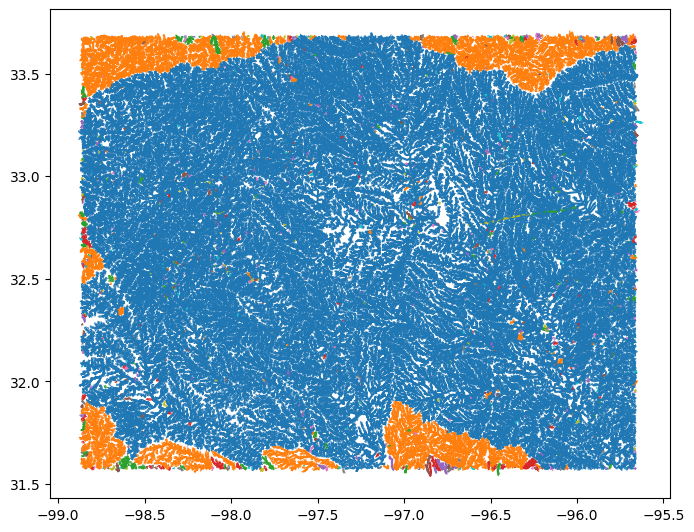

In [14]:
fig, ax = plt.subplots(figsize=(8, 8))
nhd_flowlines.plot(column='labels', cmap='tab10', ax=ax)

# Write to file for inspection in GIS

In [15]:
nhd_flowlines.to_file('../data/GIS/flowlines_connectivity.shp')

/tmp/ipykernel_78599/4180744932.py:1: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  nhd_flowlines.to_file('../data/GIS/flowlines_connectivity.shp')
/home/akagi/.local/lib/python3.11/site-packages/pyogrio/raw.py:709: RuntimeWarning: Normalized/laundered field name: 'permanent_identifier' to 'permanent_'
  ogr_write(
/home/akagi/.local/lib/python3.11/site-packages/pyogrio/raw.py:709: RuntimeWarning: Field fdate create as date field, though DateTime requested.
  ogr_write(
/home/akagi/.local/lib/python3.11/site-packages/pyogrio/raw.py:709: RuntimeWarning: Normalized/laundered field name: 'wbarea_permanent_identifier' to 'wbarea_per'
  ogr_write(
/home/akagi/.local/lib/python3.11/site-packages/pyogrio/raw.py:709: RuntimeWarning: Normalized/laundered field name: 'visibilityfilter' to 'visibility'
  ogr_write(
/home/akagi/.local/lib/python3.11/site-packages/pyogrio/raw.py:709: RuntimeWarning: Normalized/laundered field name: 'SHAPE_Leng